<a href="https://colab.research.google.com/github/Bishesh-P/Analyzing-Customer-Churn-in-Excel/blob/main/Loan_Prediction_using_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix


In [99]:
loan = pd.read_csv('/content/loan.csv')

In [100]:
loan.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [101]:
loan.drop(columns = 'Loan_ID',inplace=True)

In [102]:
loan['Gender'].value_counts()

,count
Gender,
Male,489
Female,112


In [103]:
loan['Married'].value_counts()

,count
Married,
Yes,398
No,213


In [104]:
loan['Dependents'].value_counts()

,count
Dependents,
0,345
1,102
2,101
3+,51


In [105]:
loan['Dependents'] = loan['Dependents'].str.replace('3+','3',regex = False)

In [106]:
loan['Dependents'] = pd.to_numeric(
    loan['Dependents'],
    errors='coerce'
)

In [107]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Dependents         599 non-null    float64
 3   Education          614 non-null    object 
 4   Self_Employed      582 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(5), int64(1), object(6)
memory usage: 57.7+ KB


In [108]:
loan.sample(5)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
202,Male,Yes,3.0,Not Graduate,No,3992,0.0,NaN,180.0,1.0,Urban,N
474,Male,No,2.0,Graduate,No,5532,4648.0,162.0,360.0,1.0,Rural,Y
13,Male,No,0.0,Graduate,No,1853,2840.0,114.0,360.0,1.0,Rural,N
405,Female,No,0.0,Graduate,No,4547,0.0,115.0,360.0,1.0,Semiurban,Y
77,Male,Yes,1.0,Graduate,Yes,1000,3022.0,110.0,360.0,1.0,Urban,N


In [109]:
loan.isnull().sum()

,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


In [110]:
loan.duplicated().sum()

np.int64(0)

In [111]:
#handle null values by fillna with mean , median or mode
loan['LoanAmount'].fillna(loan['LoanAmount'].mean(), inplace=True)
loan['Loan_Amount_Term'].fillna(loan['Loan_Amount_Term'].mean(), inplace=True)
loan['Credit_History'].fillna(loan['Credit_History'].mode()[0], inplace=True)
loan['Gender'].fillna(loan['Gender'].mode()[0], inplace=True)
loan['Married'].fillna(loan['Married'].mode()[0], inplace=True)
loan['Dependents'].fillna(loan['Dependents'].mode()[0], inplace=True)
loan['Self_Employed'].fillna(loan['Self_Employed'].mode()[0], inplace=True)

/tmp/ipykernel_2468/2192614126.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan['LoanAmount'].fillna(loan['LoanAmount'].mean(), inplace=True)
/tmp/ipykernel_2468/2192614126.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

In [112]:
loan.isnull().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


In [113]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    object 
 1   Married            614 non-null    object 
 2   Dependents         614 non-null    float64
 3   Education          614 non-null    object 
 4   Self_Employed      614 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(5), int64(1), object(6)
memory usage: 57.7+ KB


In [114]:
loan.describe().T

,count,mean,std,min,25%,50%,75%,max
Dependents,614.0,0.744300,1.009623,0.0,0.00,0.0,1.00,3.0
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.50,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.00,1188.5,2297.25,41667.0
LoanAmount,614.0,146.412162,84.037468,9.0,100.25,129.0,164.75,700.0
Loan_Amount_Term,614.0,342.000000,64.372489,12.0,360.00,360.0,360.00,480.0
Credit_History,614.0,0.855049,0.352339,0.0,1.00,1.0,1.00,1.0


In [115]:
loan.shape

(614, 12)

In [116]:
loan['Loan_Status'].value_counts()

,count
Loan_Status,
Y,422
N,192


In [117]:
#label encoding for target variable
loan.replace({"Loan_Status": {"Y": 1, "N": 0}}, inplace=True)
loan.head()

/tmp/ipykernel_2468/2137577156.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan.replace({"Loan_Status": {"Y": 1, "N": 0}}, inplace=True)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0.0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,1
1,Male,Yes,1.0,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,0
2,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,1
3,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,1
4,Male,No,0.0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,1


In [118]:
# Encoding categorical variables
loan['Gender'] = loan['Gender'].map({'Male': 1, 'Female': 0})
loan['Married'] = loan['Married'].map({'Yes': 1, 'No': 0})
loan['Self_Employed'] = loan['Self_Employed'].map({'Yes': 1, 'No': 0})

In [119]:
loan = pd.get_dummies(loan, columns=['Education', 'Property_Area'], drop_first=True)

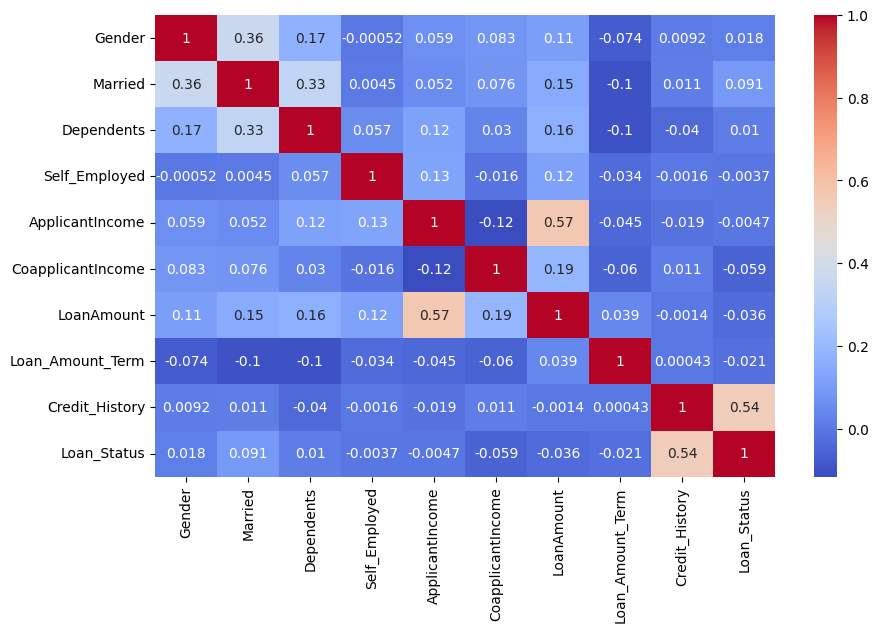

In [120]:
numeric_df = loan.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [121]:
# seperating the features and target variable
X = loan.drop('Loan_Status', axis=1)
y = loan['Loan_Status']

In [122]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [123]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit scaler on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Only transform test data
X_test_scaled = scaler.transform(X_test)

In [124]:
model = svm.SVC(kernel='linear')
model.fit(X_train_scaled, y_train)

SVC(kernel='linear')

In [125]:
#Model accuracy
X_train_pred = model.predict(X_train_scaled)
train_accuracy = accuracy_score(X_train_pred, y_train)
print(f"Train Accuracy: {train_accuracy}")
X_test_pred = model.predict(X_test_scaled)
test_accuracy = accuracy_score(X_test_pred, y_test)
print(f"Test Accuracy: {test_accuracy}")

Train Accuracy: 0.814663951120163
Test Accuracy: 0.7886178861788617


In [126]:
print(confusion_matrix(y_test, X_test_pred))
print(classification_report(y_test, X_test_pred))

[[18 25]
 [ 1 79]]
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [127]:
print(X_train.dtypes)

Gender                       int64
Married                      int64
Dependents                 float64
Self_Employed                int64
ApplicantIncome              int64
CoapplicantIncome          float64
LoanAmount                 float64
Loan_Amount_Term           float64
Credit_History             float64
Education_Not Graduate        bool
Property_Area_Semiurban       bool
Property_Area_Urban           bool
dtype: object


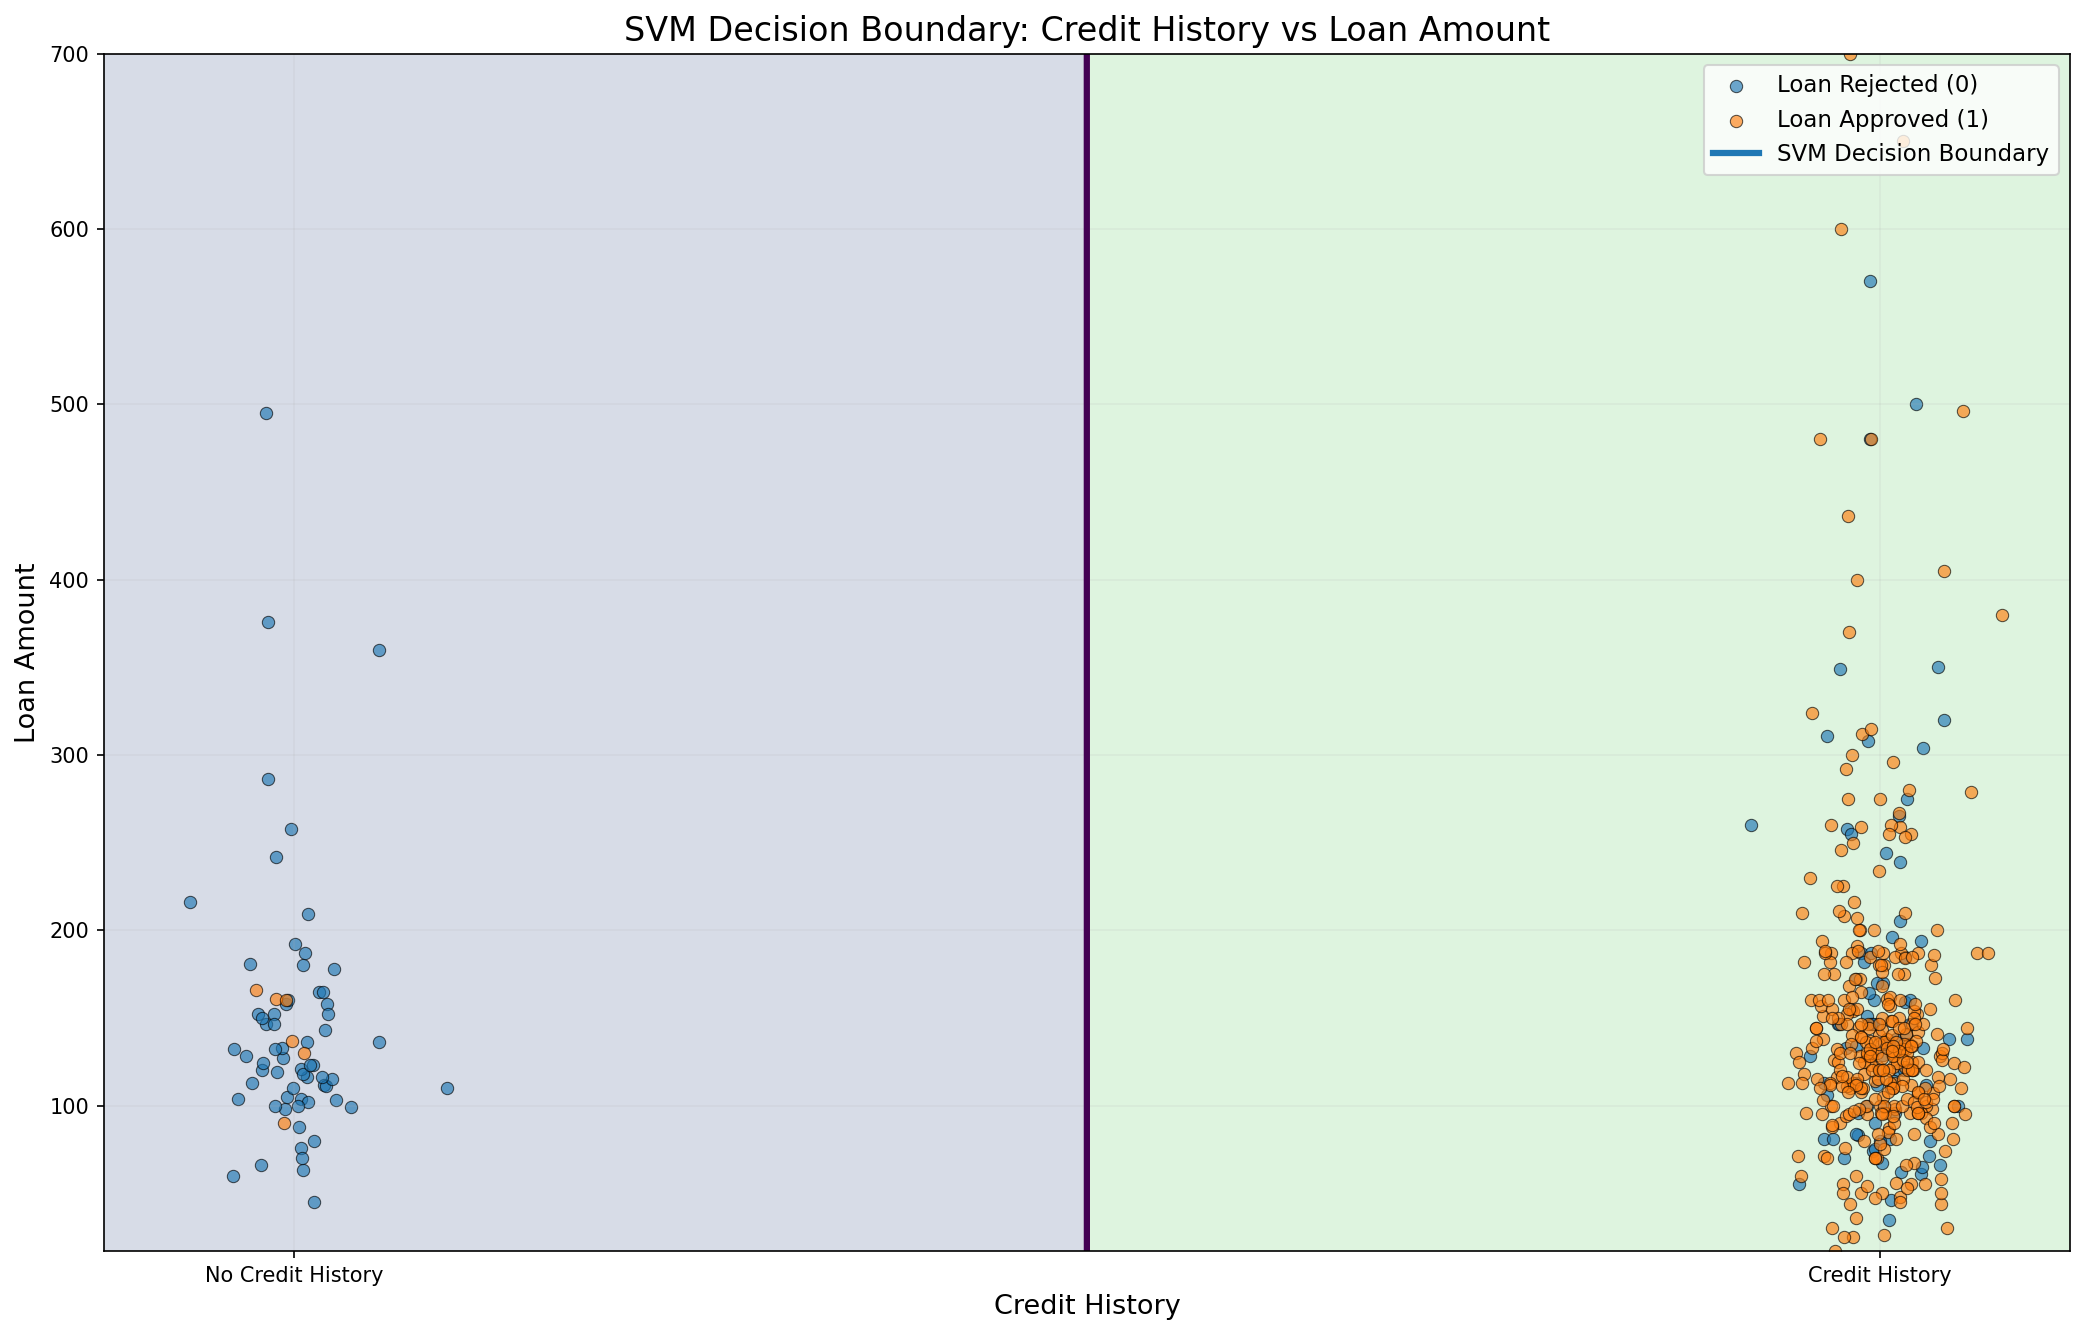

In [138]:

from matplotlib.lines import Line2D


# 1. Select the two features

feature1 = 'Credit_History'
feature2 = 'LoanAmount'



# 2. Create a grid for the SVM decision boundary


x_min = X_train[feature1].min() - 0.15
x_max = X_train[feature1].max() + 0.15

y_min = X_train[feature2].min()
y_max = X_train[feature2].max()

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)



# 3. Create representative values for the other features


representative = X_train.median()

grid = pd.DataFrame(
    np.tile(
        representative.values,
        (xx.size, 1)
    ),
    columns=X_train.columns
)


# Replace only our two selected features
grid[feature1] = xx.ravel()
grid[feature2] = yy.ravel()



# 4. Scale the grid


grid_scaled = scaler.transform(grid)



# 5. Get SVM decision values


Z = model.decision_function(grid_scaled).reshape(xx.shape)



# 6. Create the figure


plt.figure(figsize=(14, 9), dpi=150)



# 7. Decision regions


plt.contourf(
    xx,
    yy,
    Z > 0,
    alpha=0.20
)



# 8. Actual SVM decision boundary


plt.contour(
    xx,
    yy,
    Z,
    levels=[0],
    linewidths=3
)



# 9. Add jitter to Credit_History

# Credit_History only contains 0 and 1.
# Jitter prevents points from completely overlapping.

np.random.seed(42)

jitter = np.random.normal(
    0,
    0.025,
    size=len(X_train)
)

credit_history_jittered = (
    X_train[feature1].values + jitter
)



# 10. Plot Loan Rejected


mask_0 = y_train == 0

plt.scatter(
    credit_history_jittered[mask_0],
    X_train.loc[mask_0, feature2],
    s=35,
    alpha=0.65,
    edgecolors='black',
    linewidths=0.5,
    label='Loan Rejected (0)'
)



# 11. Plot Loan Approved


mask_1 = y_train == 1

plt.scatter(
    credit_history_jittered[mask_1],
    X_train.loc[mask_1, feature2],
    s=35,
    alpha=0.65,
    edgecolors='black',
    linewidths=0.5,
    label='Loan Approved (1)'
)



# 12. Add decision boundary to legend


boundary_legend = Line2D(
    [0],
    [0],
    linewidth=3,
    label='SVM Decision Boundary'
)



# 13. Get existing legend handles


handles, labels = plt.gca().get_legend_handles_labels()

handles.append(boundary_legend)
labels.append('SVM Decision Boundary')



# 14. Display legend


plt.legend(
    handles=handles,
    labels=labels,
    loc='upper right',
    fontsize=11
)



# 15. Labels and title


plt.xlabel(
    'Credit History',
    fontsize=13
)

plt.ylabel(
    'Loan Amount',
    fontsize=13
)

plt.title(
    'SVM Decision Boundary: Credit History vs Loan Amount',
    fontsize=16
)



# 16. Give Credit History some visual space


plt.xlim(-0.12, 1.12)

plt.ylim(
    y_min,
    y_max
)



# 17. Improve readability


plt.xticks(
    [0, 1],
    ['No Credit History', 'Credit History']
)

plt.grid(
    alpha=0.15
)

plt.tight_layout()

plt.show()

In [129]:
# predicting the loan status
user_input = [0,1,0,0,0,5849,0.0,146.412162,360.0,1.0,1,0]
user_input = np.array(user_input).reshape(1, -1)

if model.predict(user_input) == 1:
    print("Loan Status: Approved")
else:
    print("Loan Status: Not Approved")

Loan Status: Approved


In [130]:
import pickle

In [131]:
# Save scaler
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

# Save model
with open('loan_model.pkl', 'wb') as file:
    pickle.dump(model, file)